In [1]:
import importlib
import quantum_function
importlib.reload(quantum_function)

from quantum_function import *
from IPython.display import display, Markdown

In [2]:
# --- SAFETY SWITCH: esce subito se non abiliti esplicitamente ---
RUN_THIS_CELL = True   # metti True solo quando vuoi davvero eseguire

if not RUN_THIS_CELL:
    display(Markdown("Cell locked. Set `RUN_THIS_CELL = True` to run"))
    raise SystemExit



plt.rcParams["text.usetex"] = True
plt.rcParams.update({
    "mathtext.fontset": "cm",      # font simile a LaTeX
    "font.family": "serif",
    "font.size": 14,
    "axes.unicode_minus": False
})

<font size="6">***Inefficient photodetection - 2 qubits, single dephasing***

## Inefficient case: $|+ \! + \rangle$, $\quad \phi_1 = 0 \quad \phi_2 = 0$

$$
\left\{
\begin{aligned}
\hat{C}_1 &= e^{i \phi_{1}}\hat{C}_+ = \hat{C}_+\\
\hat{C}_2 &= e^{i \phi_{2}}\hat{C}_- = \hat{C}_-
\end{aligned}
\right.
$$

In [3]:
#1000 in 2 min

gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) 

my_label_eta = ["1", "0.9", "0.7", "0.5", "0.3"] 

my_eta = [1, 0.9, 0.7, 0.5, 0.3] #etas for the homodyne detection

state = css_2(np.pi/2, phi=0)

ineff_df = {}

my_opts_dict = {
    "keep_runs_results": False,
    #"map":"parallel",
    #"normalize_output" : False,
    #"store_final_state" : False,
    #"store_states": False,
    #"store_measurement": False,
    #"progress_bar": "Enhanced",
    "num_cpus": os.cpu_count()-1,
    }

columns_label = [
                #"Energy",
                 "Conc",
                 #"Xi2_KU",
                 #"F_phi_plus",
                 #"F_phi_minus",
                 #"F_psi_plus",
                 #"F_psi_minus"
            ]

label_graph_column = {
    #"Energy": r"Energy",
    "Conc": r"$\overline{\mathcal{C}}$",
    #"Xi2_KU": r"$\xi^2_{KU}$",
    #"F_phi_plus": r"Fidelity $|\Phi^+\rangle$",
    #"F_phi_minus": r"Fidelity $|\Phi^-\rangle$",
    #"F_psi_plus": r"Fidelity $|\Psi^+\rangle$",
    #"F_psi_minus": r"Fidelity $|\Psi^-\rangle$"
}

my_e_ops = [
    #energy_solver, 
    concurrence_for_solver_general, 
    #xi_KU_solver
    ]


ntraj = 1000


for eta,label in zip(my_eta, my_label_eta):

    my_photodetection = mcsolve(
        qutip.liouvillian(H_free, collapsing_operators(gamma, 0, 0, 1-eta)), 
        state, times,

        c_ops = collapsing_operators(gamma, 0, 0, eta),
        
        e_ops=my_e_ops,
        ntraj=ntraj,
        options=my_opts_dict
    )

    ineff_df[f"{label}"] = pd.DataFrame(np.transpose(my_photodetection.expect), columns=columns_label)


10.0%. Run time:  18.82s. Est. time left: 00:00:02:49
20.0%. Run time:  40.46s. Est. time left: 00:00:02:41
30.0%. Run time:  58.93s. Est. time left: 00:00:02:17
40.0%. Run time:  78.23s. Est. time left: 00:00:01:57
50.0%. Run time:  99.18s. Est. time left: 00:00:01:39
60.0%. Run time: 118.61s. Est. time left: 00:00:01:19
70.0%. Run time: 137.38s. Est. time left: 00:00:00:58
80.0%. Run time: 157.29s. Est. time left: 00:00:00:39
90.0%. Run time: 177.19s. Est. time left: 00:00:00:19
100.0%. Run time: 196.72s. Est. time left: 00:00:00:00
Total run time: 197.18s
10.0%. Run time:  19.63s. Est. time left: 00:00:02:56
20.0%. Run time:  38.90s. Est. time left: 00:00:02:35
30.0%. Run time:  58.56s. Est. time left: 00:00:02:16
40.0%. Run time:  77.53s. Est. time left: 00:00:01:56
50.0%. Run time:  97.19s. Est. time left: 00:00:01:37
60.0%. Run time: 116.37s. Est. time left: 00:00:01:17
70.0%. Run time: 135.26s. Est. time left: 00:00:00:57
80.0%. Run time: 156.07s. Est. time left: 00:00:00:39
90.

In [5]:
theo_curves = [np.exp(-(1-eta)*times)*(1-np.exp(-gamma*eta/2*times)) for eta in my_eta]

my_directory = ".\\Graphs\\Jz_3_Ineff_Photodetection\\phi_1=0_phi_2=0"
Path(my_directory).mkdir(parents=True, exist_ok=True)

for e_op in columns_label:
    #Un graph per ogni e_op, al variare di eta
    plt.figure(figsize=(12,8))
    graph_name = f"Ineff_{e_op}"

    for (label, df), eta, theory in zip(ineff_df.items(), my_eta, theo_curves):
        # x: tempo normalizzato a T1, y: media delle traiettorie
        x = times/T_1
        y = df[e_op]
        line_sim, = plt.plot(x, y, label=r"$\eta$ = " + str(eta))
        plt.plot(times/T_1, theory, '--', color=line_sim.get_color(), alpha=0.5, linewidth=2)

    #plt.ylim(-0.01, 1.02)
    plt.xlim(0,10)

    #plt.axhline(1, color="k", linewidth=1.6, linestyle="-", zorder=5)
    #plt.axhspan(1, 1.05, color="k", alpha=0.7, zorder=1, label="_nolegend_")

    plt.xlabel(r"$t/T_1$")
    plt.ylabel(label_graph_column[e_op])

    plt.title(r"Inefficient Photodetection: Average " + label_graph_column[e_op]+ r" over time"+ rf"$, \phi_1 = 0 \quad \phi_2 = 0$"
            + rf"  (n$_\mathrm{{traj}}$ = {ntraj})")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)

    plt.savefig(Path(my_directory) / f"{graph_name}.pdf", bbox_inches="tight")
    plt.show()

RuntimeError: Failed to process string with tex because latex could not be found

Error in callback <function _draw_all_if_interactive at 0x000001AA32CC7F60> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 1200x800 with 1 Axes>

## Inefficient case: $|+ \! + \rangle$, $\quad \phi_1 = 0 \quad \phi_2 = \pi/2$

$$
\left\{
\begin{aligned}
\hat{C}_1 &= e^{i \phi_{1}}\hat{C}_+ = \hat{C}_+\\
\hat{C}_2 &= e^{i \phi_{2}}\hat{C}_- = i\,\hat{C}_-
\end{aligned}
\right.
$$

In [5]:
my_e_ops = [energy_solver, concurrence_for_solver_general, xi_KU_solver]+fidelity_ops
my_e_ops

[<function quantum_function.energy_solver(t, state)>,
 <function quantum_function.concurrence_for_solver_general(t, state)>,
 <function quantum_function.xi_KU_solver(t, rho, N=None, tol=1e-12)>,
 <function quantum_function.fidelity_phi_plus_solver(t, rho)>,
 <function quantum_function.fidelity_phi_minus_solver(t, rho)>,
 <function quantum_function.fidelity_psi_plus_solver(t, rho)>,
 <function quantum_function.fidelity_psi_minus_solver(t, rho)>]

In [10]:
#1000 in 2 min

gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) 

my_label_eta = ["1", "0.7", "0.5"] 

my_eta = [1, 0.7, 0.5] #etas for the homodyne detection

state = PlusPlus

ineff_df = {}

my_opts_dict = {
    "keep_runs_results": False,
    #"map":"parallel",
    #"normalize_output" : False,
    #"store_final_state" : False,
    #"store_states": False,
    #"store_measurement": False,
    #"progress_bar": "Enhanced",
    "num_cpus": os.cpu_count()-1,
    }

columns_label = ["Energy",
                 "Conc",
                 "Xi2_KU",
                 "F_phi_plus",
                 "F_phi_minus",
                 "F_psi_plus",
                 "F_psi_minus"
            ]


ntraj = 100

for eta,label in zip(my_eta, my_label_eta):
    my_photodetection = mcsolve(
        qutip.liouvillian(H_free, collapsing_operators(gamma, 0, np.pi/2., 1-eta)), 
        state, times,

        c_ops = collapsing_operators(gamma, 0, np.pi/2., eta),

        e_ops=my_e_ops,
        ntraj=ntraj,
        options=my_opts_dict
    )

    ineff_df[f"{label}"] = pd.DataFrame(np.transpose(my_photodetection.expect), columns=columns_label)

10.0%. Run time:  11.12s. Est. time left: 00:00:01:40
20.0%. Run time:  22.40s. Est. time left: 00:00:01:29
30.0%. Run time:  33.25s. Est. time left: 00:00:01:17
40.0%. Run time:  44.24s. Est. time left: 00:00:01:06
50.0%. Run time:  56.14s. Est. time left: 00:00:00:56
60.0%. Run time:  69.30s. Est. time left: 00:00:00:46
70.0%. Run time:  80.83s. Est. time left: 00:00:00:34
80.0%. Run time:  91.81s. Est. time left: 00:00:00:22
90.0%. Run time: 103.30s. Est. time left: 00:00:00:11
100.0%. Run time: 114.84s. Est. time left: 00:00:00:00
Total run time: 115.99s
10.0%. Run time:  10.07s. Est. time left: 00:00:01:30
20.0%. Run time:  20.96s. Est. time left: 00:00:01:23
30.0%. Run time:  31.97s. Est. time left: 00:00:01:14
40.0%. Run time:  43.15s. Est. time left: 00:00:01:04
50.0%. Run time:  54.17s. Est. time left: 00:00:00:54
60.0%. Run time:  64.99s. Est. time left: 00:00:00:43
70.0%. Run time:  75.97s. Est. time left: 00:00:00:32
80.0%. Run time:  86.94s. Est. time left: 00:00:00:21
90.

In [8]:
ineff_df["0.7"]

,Energy,Conc,Xi2_KU,F_phi_plus,F_phi_minus,F_psi_plus,F_psi_minus
0,0.0,0.000000,1.000000,0.707107,0.000000,0.707107,0.000000
1,0.0,0.000000,1.000000,0.706577,0.027366,0.706577,0.027366
2,0.0,0.099402,0.900598,0.640913,0.134655,0.635444,0.034805
3,0.0,0.099104,0.900896,0.641662,0.142371,0.634969,0.042595
4,0.0,0.098807,0.901193,0.642218,0.148849,0.634495,0.049148
...,...,...,...,...,...,...,...
995,0.0,0.050540,0.664622,0.489454,0.500179,0.213852,0.210277
996,0.0,0.050388,0.664728,0.489471,0.500164,0.213847,0.210283
997,0.0,0.050237,0.664834,0.489488,0.500149,0.213842,0.210288
998,0.0,0.050087,0.664939,0.489505,0.500134,0.213837,0.210294


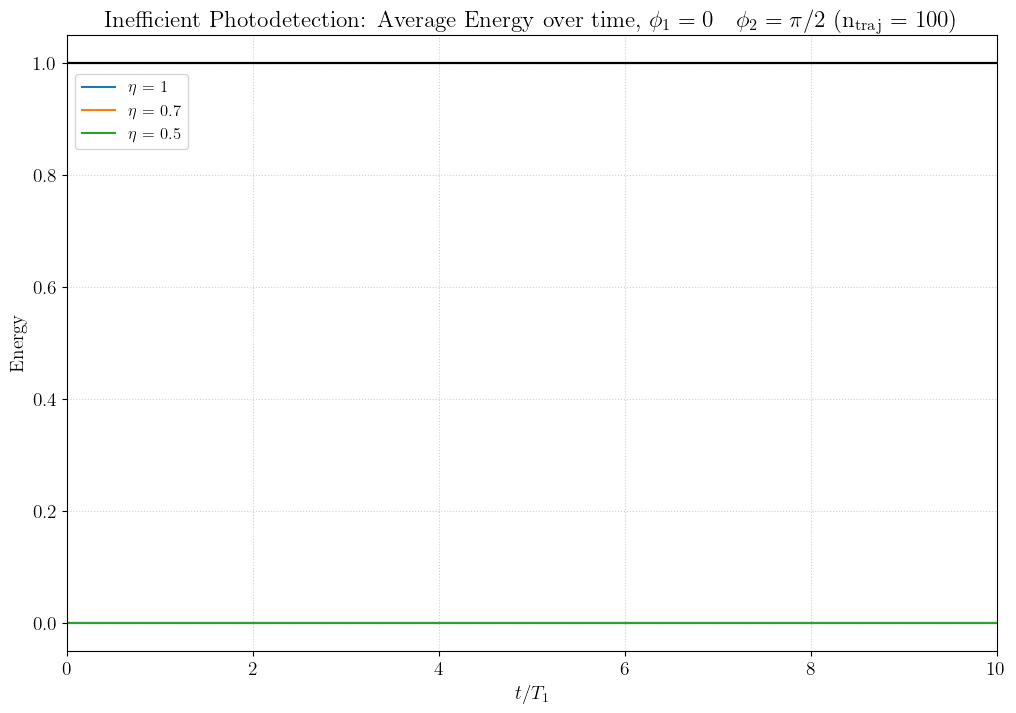

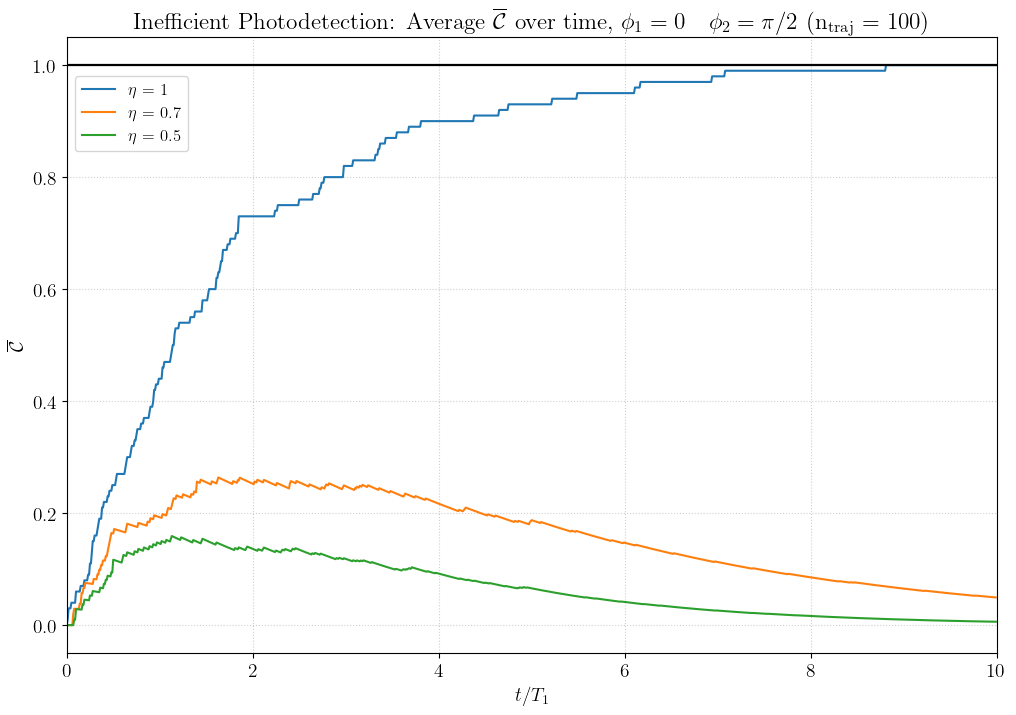

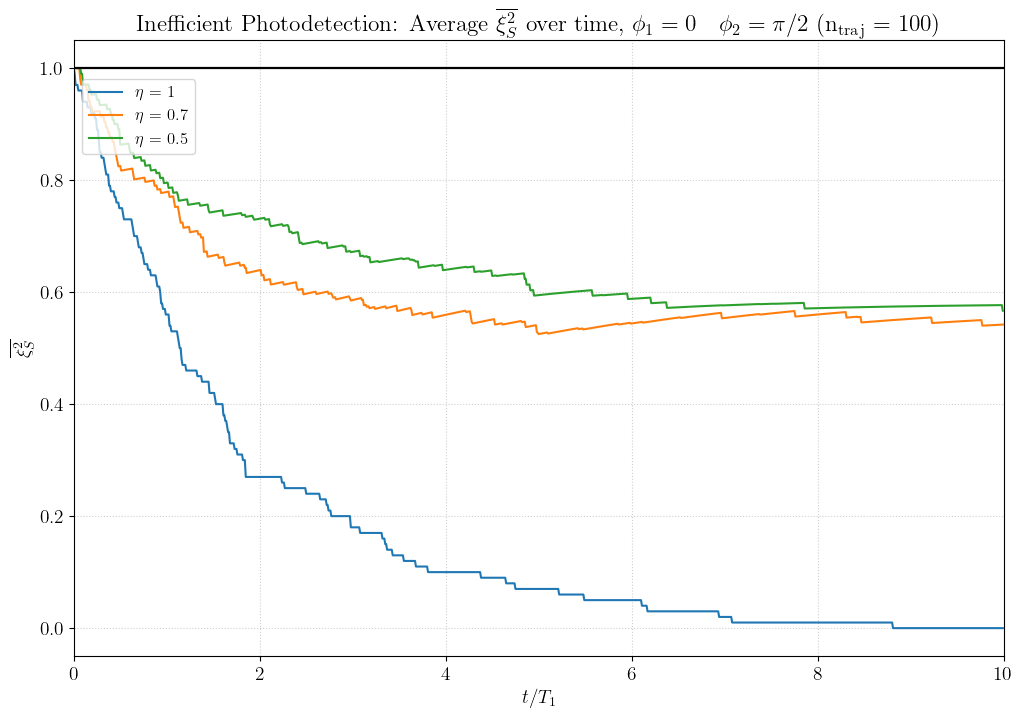

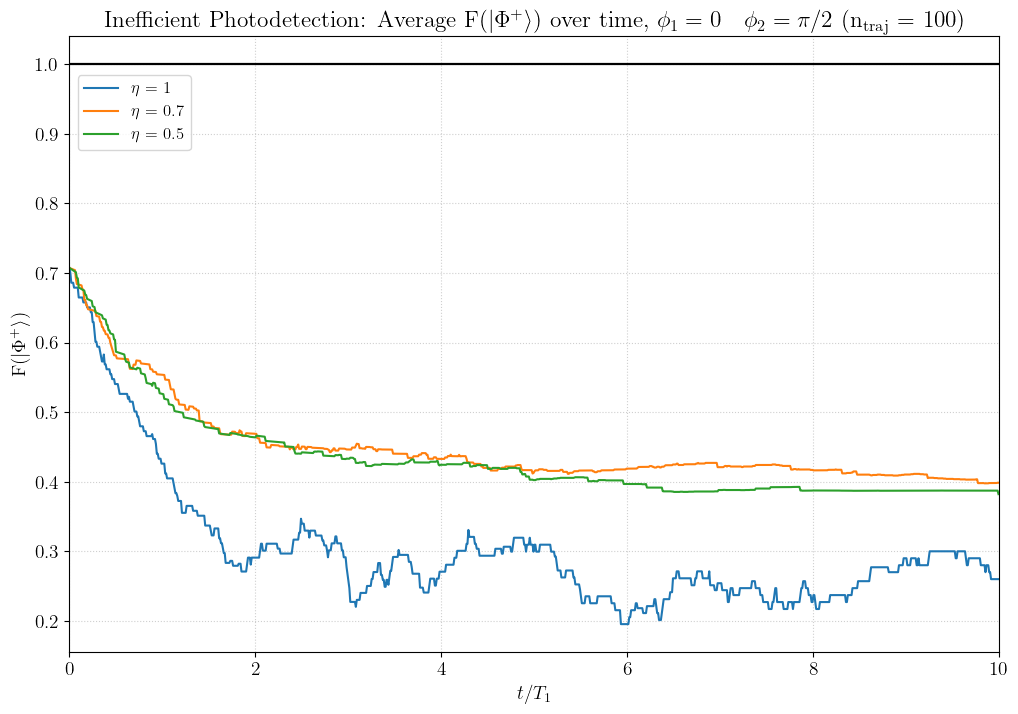

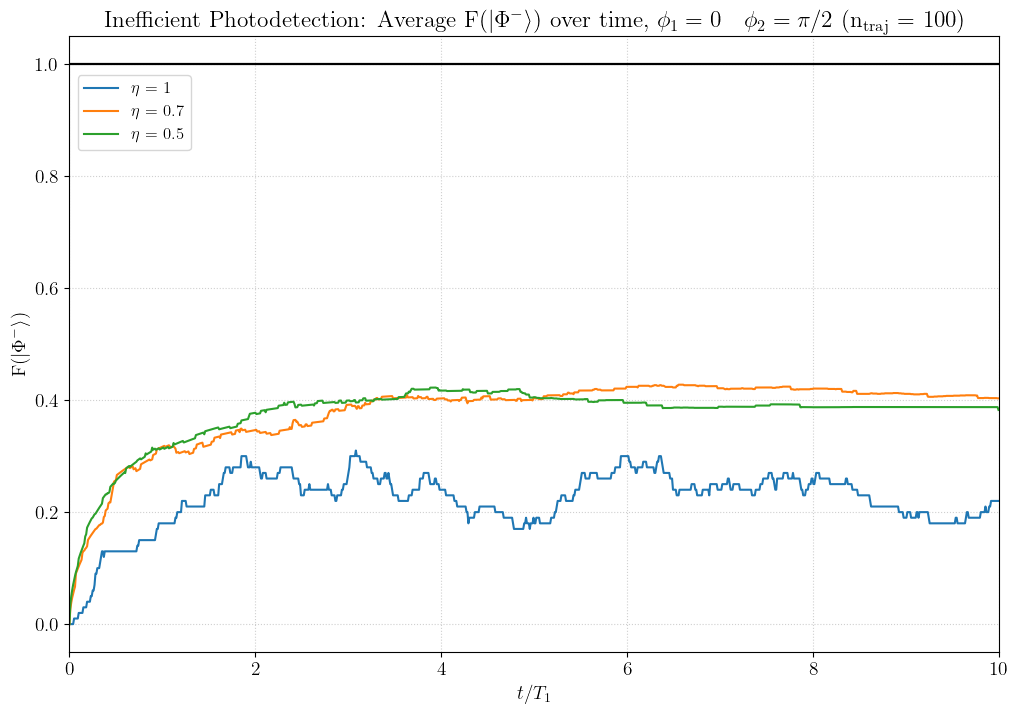

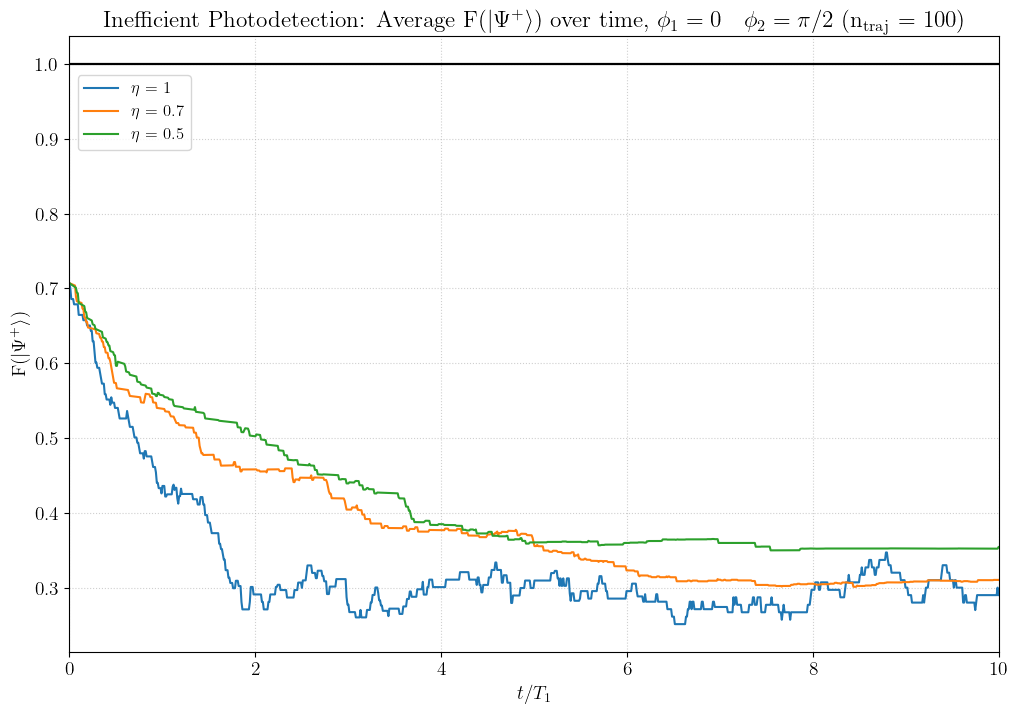

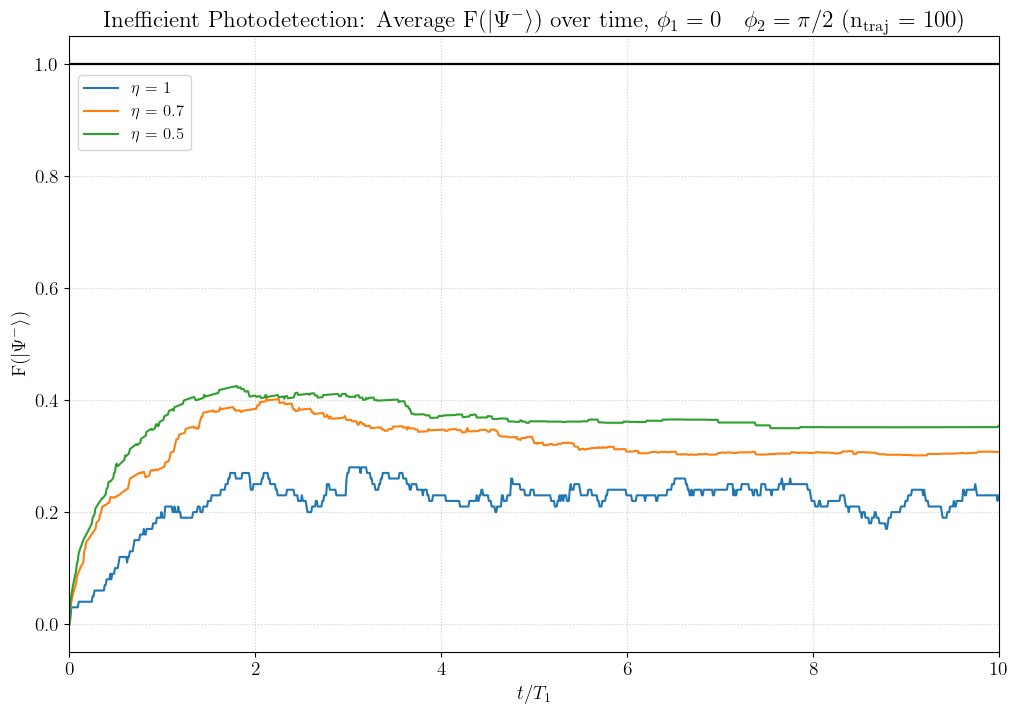

In [11]:
#theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

my_directory = ".\\Graphs\\Jz_3_Ineff_Photodetection\\phi_1=0_phi_2=pi2"
Path(my_directory).mkdir(parents=True, exist_ok=True)


label_graph_column = {
    "Energy": r"Energy",
    "Conc": r"$\overline{\mathcal{C}}$",
    "Xi2_KU": r"$\overline{\xi^2_{S}}$",
    "F_phi_plus": r"F$(|\Phi^+\rangle)$",
    "F_phi_minus": r"F$(|\Phi^-\rangle)$",
    "F_psi_plus": r"F$(|\Psi^+\rangle)$",
    "F_psi_minus": r"F$(|\Psi^-\rangle)$"
}


for e_op in columns_label:
    #Un graph per ogni e_op, al variare di eta
    plt.figure(figsize=(12,8))
    graph_name = f"Ineff_{e_op}_phi_1=0_phi_2=pi2"

    for (label, df), eta in zip(ineff_df.items(), my_eta):
        # x: tempo normalizzato a T1, y: media delle traiettorie
        x = times/T_1
        y = df[e_op]
        line_sim, = plt.plot(x, y, label=r"$\eta$ = " + str(eta))
        #plt.plot(times/T_1, theory, '--', color=line_sim.get_color(), alpha=0.5, linewidth=2)

    #plt.ylim(-0.01, 1.02)
    plt.xlim(0,10)

    plt.axhline(1, color="k", linewidth=1.6, linestyle="-", zorder=5)
    #plt.axhspan(1, 1.05, color="k", alpha=0.7, zorder=1, label="_nolegend_")

    plt.xlabel(r"$t/T_1$")
    plt.ylabel(label_graph_column[e_op])

    plt.title(r"Inefficient Photodetection: Average " + label_graph_column[e_op]+ r" over time, "+ rf"$\phi_1 = 0 \quad \phi_2 = \pi / 2$"
            + rf"  (n$_\mathrm{{traj}}$ = {ntraj})")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)

    plt.savefig(Path(my_directory) / f"{graph_name}.pdf", bbox_inches="tight")
    plt.show()

## Inefficient case: $|+ \! + \rangle$, $\quad \phi_1 = \pi/2 \quad \phi_2 = 0$

$$
\left\{
\begin{aligned}
\hat{C}_1 &= e^{i \phi_{1}}\hat{C}_+ = i\hat{C}_+\\
\hat{C}_2 &= e^{i \phi_{2}}\hat{C}_- = \hat{C}_-
\end{aligned}
\right.
$$

In [61]:
#1000 in 2 min

gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) 

my_label_eta = ["1", "0.7", "0.5"] 

my_eta = [1, 0.7, 0.5] #etas for the homodyne detection

state = PlusPlus

ineff_df = {}

my_opts_dict = {
    "keep_runs_results": False,
    #"map":"parallel",
    #"normalize_output" : False,
    #"store_final_state" : False,
    #"store_states": False,
    #"store_measurement": False,
    #"progress_bar": "Enhanced",
    "num_cpus": os.cpu_count()-1,
    }

columns_label = ["Energy",
                 "Conc",
                 "Xi2_KU",
                 #"F_phi_plus",
                 #"F_phi_minus",
                 #"F_psi_plus",
                 #"F_psi_minus"
            ]

label_graph_column = {
    "Energy": r"Energy",
    "Conc": r"$\overline{\mathcal{C}}$",
    "Xi2_KU": r"$\xi^2_{KU}$",
    #"F_phi_plus": r"Fidelity $|\Phi^+\rangle$",
    #"F_phi_minus": r"Fidelity $|\Phi^-\rangle$",
    #"F_psi_plus": r"Fidelity $|\Psi^+\rangle$",
    #"F_psi_minus": r"Fidelity $|\Psi^-\rangle$"
}

my_e_ops = [energy_solver, concurrence_for_solver_general, xi_KU_solver]


ntraj = 500

for eta,label in zip(my_eta, my_label_eta):
    my_photodetection = smesolve(
        H_free, state, times,

        c_ops = [
        np.exp(1j * np.pi/2)*np.sqrt(gamma*(1-eta) / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma*(1-eta) / 2) * (Sz_1-Sz_2)
        ],

        sc_ops = [
        np.exp(1j * np.pi/2)*np.sqrt(gamma*eta / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma*eta/ 2) * (Sz_1-Sz_2)
        ],

        e_ops=my_e_ops,
        ntraj=ntraj,
        options=my_opts_dict
    )

    ineff_df[f"{label}"] = pd.DataFrame(np.transpose(my_photodetection.expect), columns=columns_label)

10.0%. Run time:  78.49s. Est. time left: 00:00:11:46
20.0%. Run time: 154.34s. Est. time left: 00:00:10:17
30.0%. Run time: 228.70s. Est. time left: 00:00:08:53
40.0%. Run time: 306.31s. Est. time left: 00:00:07:39
50.0%. Run time: 380.85s. Est. time left: 00:00:06:20
60.0%. Run time: 459.28s. Est. time left: 00:00:05:06
70.0%. Run time: 537.29s. Est. time left: 00:00:03:50
80.0%. Run time: 613.92s. Est. time left: 00:00:02:33
90.0%. Run time: 690.19s. Est. time left: 00:00:01:16
100.0%. Run time: 767.77s. Est. time left: 00:00:00:00
Total run time: 769.79s
10.0%. Run time:  72.54s. Est. time left: 00:00:10:52
20.0%. Run time: 145.05s. Est. time left: 00:00:09:40
30.0%. Run time: 220.70s. Est. time left: 00:00:08:34
40.0%. Run time: 296.21s. Est. time left: 00:00:07:24
50.0%. Run time: 372.45s. Est. time left: 00:00:06:12
60.0%. Run time: 450.23s. Est. time left: 00:00:05:00
70.0%. Run time: 526.19s. Est. time left: 00:00:03:45
80.0%. Run time: 600.87s. Est. time left: 00:00:02:30
90.

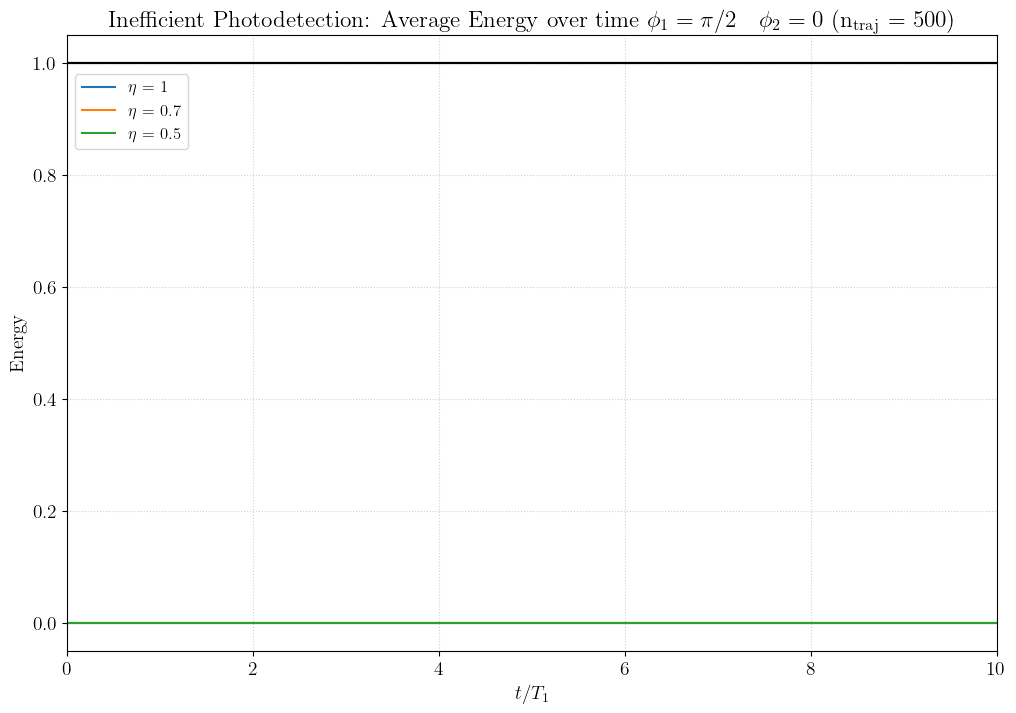

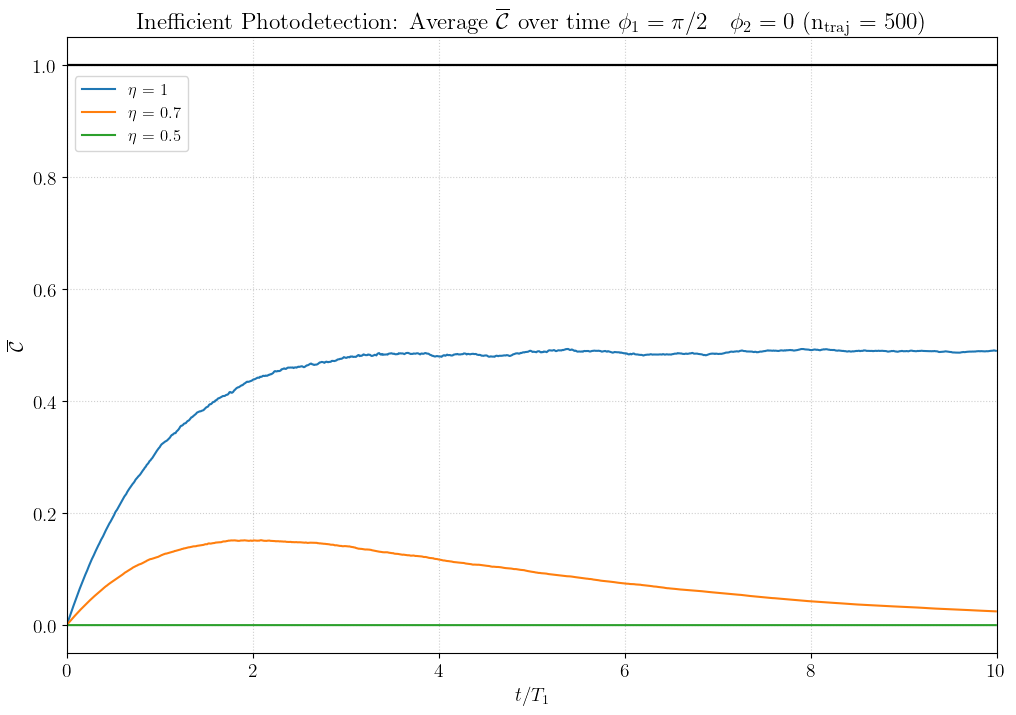

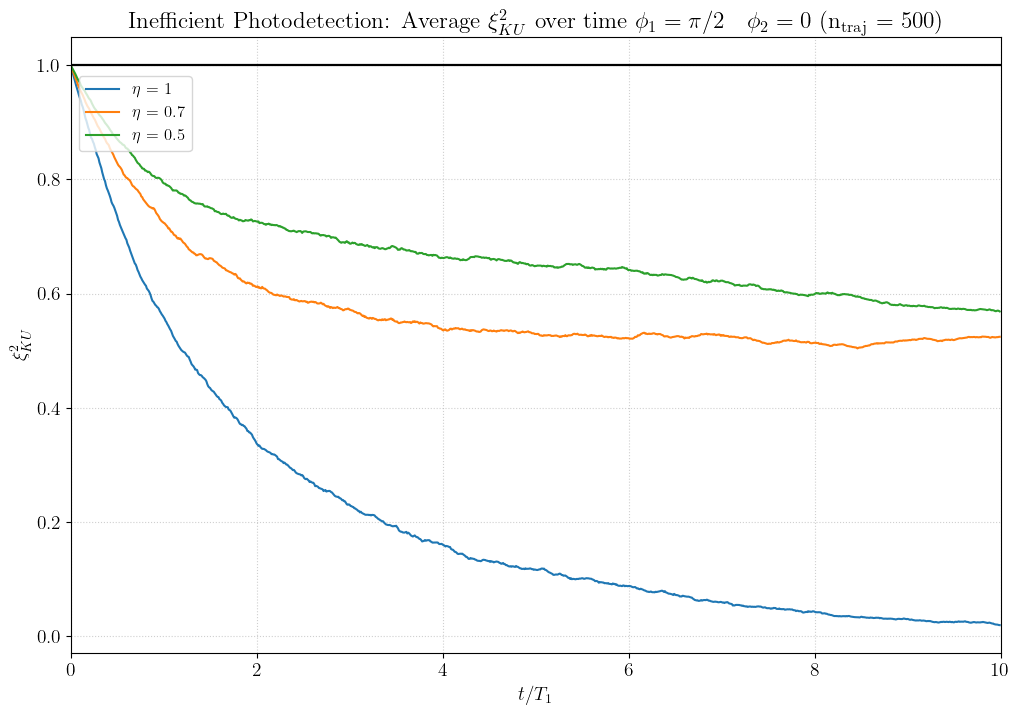

In [62]:
#theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

my_directory = ".\\Graphs\\Jz_3_Ineff_Photodetection\\phi_1=pi_2_phi_2=0"
Path(my_directory).mkdir(parents=True, exist_ok=True)

for e_op in columns_label:
    #Un graph per ogni e_op, al variare di eta
    plt.figure(figsize=(12,8))
    graph_name = f"Ineff_{e_op}"

    for (label, df), eta in zip(ineff_df.items(), my_eta):
        # x: tempo normalizzato a T1, y: media delle traiettorie
        x = times/T_1
        y = df[e_op]
        line_sim, = plt.plot(x, y, label=r"$\eta$ = " + str(eta))
        #plt.plot(times/T_1, theory, '--', color=line_sim.get_color(), alpha=0.5, linewidth=2)

    #plt.ylim(-0.01, 1.02)
    plt.xlim(0,10)

    plt.axhline(1, color="k", linewidth=1.6, linestyle="-", zorder=5)
    #plt.axhspan(1, 1.05, color="k", alpha=0.7, zorder=1, label="_nolegend_")

    plt.xlabel(r"$t/T_1$")
    plt.ylabel(label_graph_column[e_op])

    plt.title(r"Inefficient Photodetection: Average " + label_graph_column[e_op]+ r" over time"+ rf" $\phi_1 = \pi / 2 \quad \phi_2 = 0$"
            + rf"  (n$_\mathrm{{traj}}$ = {ntraj})")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)

    plt.savefig(Path(my_directory) / f"{graph_name}.pdf", bbox_inches="tight")
    plt.show()

## Inefficient case: $|+ \! + \rangle$, $\quad \phi_1 = \pi/2 \quad \phi_2 = \pi/2$

$$
\left\{
\begin{aligned}
\hat{C}_1 &= e^{i \phi_{1}}\hat{C}_+ = i\hat{C}_+\\
\hat{C}_2 &= e^{i \phi_{2}}\hat{C}_- = i\hat{C}_-
\end{aligned}
\right.
$$

In [63]:
#1000 in 2 min

gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) 

my_label_eta = ["1", "0.7", "0.5"] 

my_eta = [1, 0.7, 0.5] #etas for the homodyne detection

state = PlusPlus

ineff_df = {}

my_opts_dict = {
    "keep_runs_results": False,
    #"map":"parallel",
    #"normalize_output" : False,
    #"store_final_state" : False,
    #"store_states": False,
    #"store_measurement": False,
    #"progress_bar": "Enhanced",
    "num_cpus": os.cpu_count()-1,
    }

columns_label = ["Energy",
                 "Conc",
                 "Xi2_KU",
                 #"F_phi_plus",
                 #"F_phi_minus",
                 #"F_psi_plus",
                 #"F_psi_minus"
            ]

label_graph_column = {
    "Energy": r"Energy",
    "Conc": r"$\overline{\mathcal{C}}$",
    "Xi2_KU": r"$\xi^2_{KU}$",
    #"F_phi_plus": r"Fidelity $|\Phi^+\rangle$",
    #"F_phi_minus": r"Fidelity $|\Phi^-\rangle$",
    #"F_psi_plus": r"Fidelity $|\Psi^+\rangle$",
    #"F_psi_minus": r"Fidelity $|\Psi^-\rangle$"
}

my_e_ops = [energy_solver, concurrence_for_solver_general, xi_KU_solver]


ntraj = 500

for eta,label in zip(my_eta, my_label_eta):
    my_photodetection = smesolve(
        H_free, state, times,

        c_ops = [
        np.exp(1j * np.pi/2)*np.sqrt(gamma*(1-eta) / 2) * (Sz_1+Sz_2),
        np.exp(1j * np.pi/2)*np.sqrt(gamma*(1-eta) / 2) * (Sz_1-Sz_2)
        ],

        sc_ops = [
        np.exp(1j * np.pi/2)*np.sqrt(gamma*eta / 2) * (Sz_1+Sz_2),
        np.exp(1j * np.pi/2)*np.sqrt(gamma*eta/ 2) * (Sz_1-Sz_2)
        ],

        e_ops=my_e_ops,
        ntraj=ntraj,
        options=my_opts_dict
    )

    ineff_df[f"{label}"] = pd.DataFrame(np.transpose(my_photodetection.expect), columns=columns_label)

10.0%. Run time:  74.75s. Est. time left: 00:00:11:12
20.0%. Run time: 148.59s. Est. time left: 00:00:09:54
30.0%. Run time: 223.16s. Est. time left: 00:00:08:40
40.0%. Run time: 299.77s. Est. time left: 00:00:07:29
50.0%. Run time: 376.32s. Est. time left: 00:00:06:16
60.0%. Run time: 451.65s. Est. time left: 00:00:05:01
70.0%. Run time: 527.98s. Est. time left: 00:00:03:46
80.0%. Run time: 602.48s. Est. time left: 00:00:02:30
90.0%. Run time: 677.25s. Est. time left: 00:00:01:15
100.0%. Run time: 753.31s. Est. time left: 00:00:00:00
Total run time: 754.72s
10.0%. Run time:  81.04s. Est. time left: 00:00:12:09
20.0%. Run time: 162.13s. Est. time left: 00:00:10:48
30.0%. Run time: 244.73s. Est. time left: 00:00:09:31
40.0%. Run time: 321.77s. Est. time left: 00:00:08:02
50.0%. Run time: 399.73s. Est. time left: 00:00:06:39
60.0%. Run time: 479.71s. Est. time left: 00:00:05:19
70.0%. Run time: 556.20s. Est. time left: 00:00:03:58
80.0%. Run time: 631.65s. Est. time left: 00:00:02:37
90.

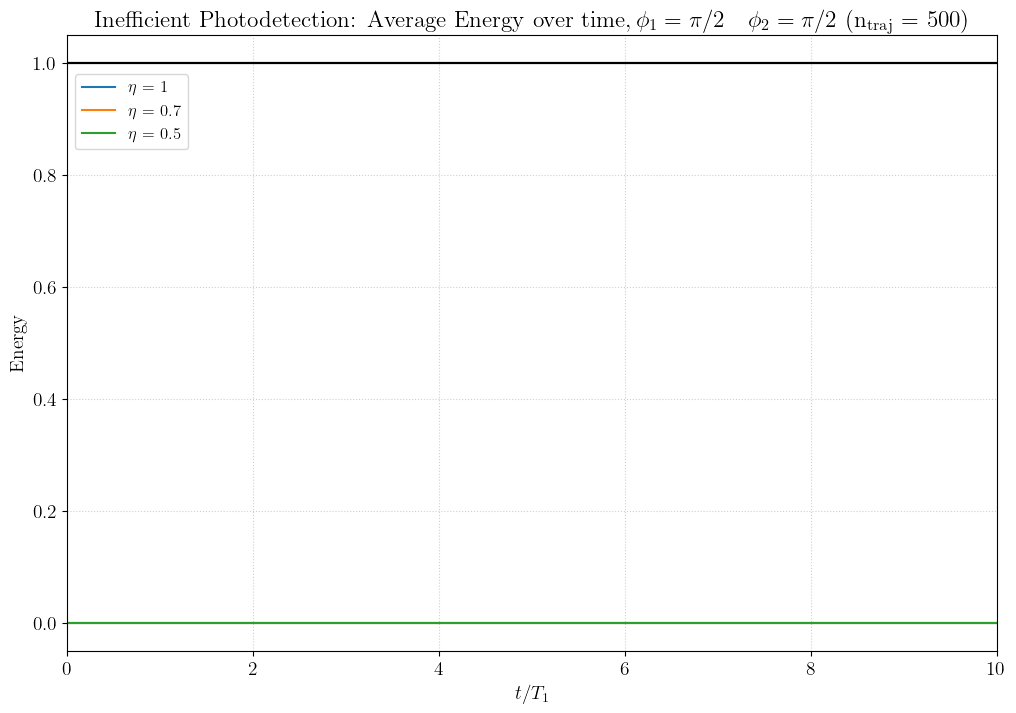

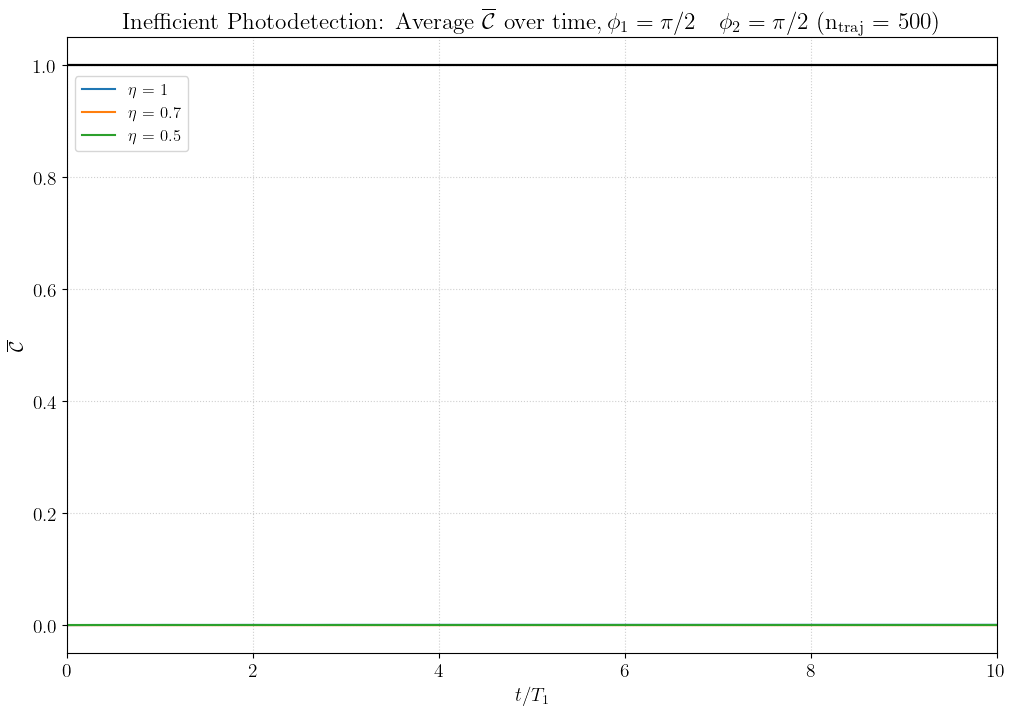

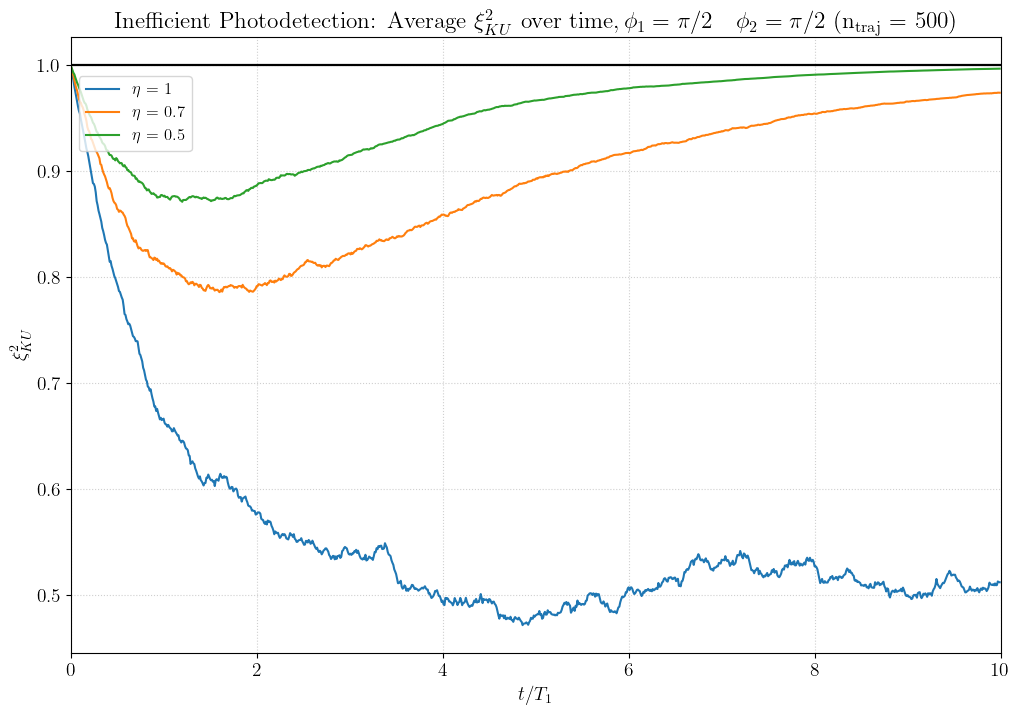

In [64]:
#theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

my_directory = ".\\Graphs\\Jz_3_Ineff_Photodetection\\phi_1=pi_2_phi_2=pi_2"
Path(my_directory).mkdir(parents=True, exist_ok=True)

for e_op in columns_label:
    #Un graph per ogni e_op, al variare di eta
    plt.figure(figsize=(12,8))
    graph_name = f"Ineff_{e_op}"

    for (label, df), eta in zip(ineff_df.items(), my_eta):
        # x: tempo normalizzato a T1, y: media delle traiettorie
        x = times/T_1
        y = df[e_op]
        line_sim, = plt.plot(x, y, label=r"$\eta$ = " + str(eta))
        #plt.plot(times/T_1, theory, '--', color=line_sim.get_color(), alpha=0.5, linewidth=2)

    #plt.ylim(-0.01, 1.02)
    plt.xlim(0,10)

    plt.axhline(1, color="k", linewidth=1.6, linestyle="-", zorder=5)
    #plt.axhspan(1, 1.05, color="k", alpha=0.7, zorder=1, label="_nolegend_")

    plt.xlabel(r"$t/T_1$")
    plt.ylabel(label_graph_column[e_op])

    plt.title(r"Inefficient Photodetection: Average " + label_graph_column[e_op]+ r" over time"+ rf"$, \phi_1 = \pi / 2 \quad \phi_2 = \pi / 2$"
            + rf"  (n$_\mathrm{{traj}}$ = {ntraj})")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)

    plt.savefig(Path(my_directory) / f"{graph_name}.pdf", bbox_inches="tight")
    plt.show()